# 2.1 理论计算题答案

## 1. 非线性激活函数的重要性

假设输入为 $\mathbf{x} \in \mathbb{R}^{n}$，隐藏层为：

$$
\mathbf{h} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1
$$

输出层为：

$$
\mathbf{o} = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2
$$

将 $\mathbf{h}$ 代入输出层：

$$
\mathbf{o} = \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2
$$

展开：

$$
\mathbf{o} = (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$

令：

$$
\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1
$$

$$
\mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$

则：

$$
\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'
$$

这是一个**单层线性神经网络**（没有隐藏层）。因此，如果没有非线性激活函数，多层感知机退化为线性模型，无法拟合非线性函数。

---

## 2. 激活函数性质分析

### Sigmoid 函数

数学表达式：

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

导数推导：

$$
\sigma'(x) = \frac{e^{-x}}{(1 + e^{-x})^2} = \sigma(x) \cdot (1 - \sigma(x))
$$

所以：

$$
\boxed{\sigma'(x) = \sigma(x) (1 - \sigma(x))}
$$

---

### Tanh 函数

数学表达式：

$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

导数推导：

$$
\tanh'(x) = 1 - \tanh^2(x)
$$

所以：

$$
\boxed{\tanh'(x) = 1 - \tanh^2(x)}
$$

Epoch  1/10 | Loss: 0.5676 | Test Acc: 0.8178
Epoch  2/10 | Loss: 0.4015 | Test Acc: 0.7999
Epoch  3/10 | Loss: 0.3615 | Test Acc: 0.8551
Epoch  4/10 | Loss: 0.3332 | Test Acc: 0.8548
Epoch  5/10 | Loss: 0.3147 | Test Acc: 0.8620
Epoch  6/10 | Loss: 0.2986 | Test Acc: 0.8697
Epoch  7/10 | Loss: 0.2856 | Test Acc: 0.8631
Epoch  8/10 | Loss: 0.2754 | Test Acc: 0.8519
Epoch  9/10 | Loss: 0.2633 | Test Acc: 0.8732
Epoch 10/10 | Loss: 0.2540 | Test Acc: 0.8692


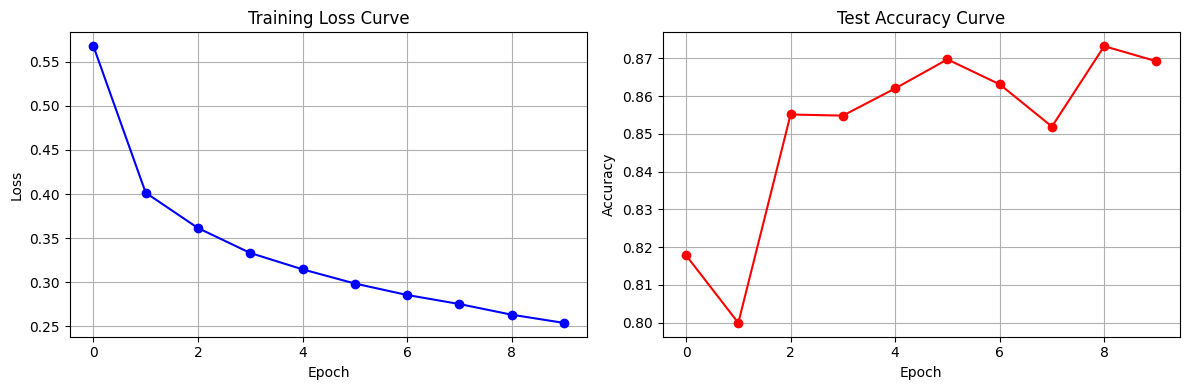


最终测试准确率: 0.8692


In [3]:
# 2.2 从零实现单隐藏层 MLP 多分类（Fashion-MNIST）

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 加载数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 1. 手动初始化参数（正态分布）
input_size, hidden_size, output_size = 784, 256, 10
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)
W1.requires_grad_(True); b1.requires_grad_(True); W2.requires_grad_(True); b2.requires_grad_(True)

# 2. ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# 3. Softmax + 交叉熵损失
def cross_entropy_softmax(logits, y):
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    return -torch.log(probs[range(logits.shape[0]), y] + 1e-8).mean()

# 训练记录
train_losses, test_accs = [], []

# 4. 训练循环（小批量 SGD 手动更新参数）
epochs, lr = 10, 0.1
for epoch in range(epochs):
    epoch_loss = 0.0
    for images, labels in train_loader:
        x = images.view(images.shape[0], -1)
        h = relu(x @ W1 + b1)
        logits = h @ W2 + b2
        loss = cross_entropy_softmax(logits, labels)
        epoch_loss += loss.item()
        
        if W1.grad is not None:
            W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
        loss.backward()
        
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            x = images.view(images.shape[0], -1)
            h = relu(x @ W1 + b1)
            logits = h @ W2 + b2
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.shape[0]
    test_acc = correct / total
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Test Acc: {test_acc:.4f}")

# 可视化损失曲线和准确率曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accs, 'r-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n最终测试准确率: {test_accs[-1]:.4f}")

# 3.1 理论计算题答案

## 1. 过拟合与欠拟合

### 训练误差与泛化误差的区别

**训练误差**：模型在训练数据集上计算得到的误差，反映模型对训练数据的拟合程度。

**泛化误差**：模型在未见过的测试数据（新数据）上计算得到的误差，反映模型的真实预测能力。

### 过拟合状态

当一个模型的训练误差极低，但泛化误差很高时，模型处于**过拟合**状态。这意味着模型过度学习了训练数据中的噪声和细节，而没有学到数据的普遍规律。

### 通过控制模型复杂度缓解过拟合

1. **降低模型复杂度**：
   - 减少网络层数
   - 减少隐藏层神经元数量

2. **正则化**：
   - L1 正则化（产生稀疏权重）
   - L2 正则化（权重衰减）

3. **早停**：在验证集误差开始上升时停止训练

4. **数据增强**：增加训练数据多样性

5. **Dropout**：随机丢弃部分神经元

---

## 2. K 折交叉验证

### 实施算法步骤

**输入**：数据集 $D$，折数 $K$，学习算法 $A$

**输出**：模型性能评估结果

**步骤**：

1. **数据划分**：将数据集 $D$ 随机打乱，平均分成 $K$ 个互不相交的子集 $D_1, D_2, \ldots, D_K$，每个子集大小相等（或近似相等）

2. **循环验证**：对于 $i = 1$ 到 $K$：
   - 将 $D_i$ 作为**验证集**
   - 将其余 $K-1$ 个子集的并集作为**训练集**
   - 在训练集上使用算法 $A$ 训练模型
   - 在验证集 $D_i$ 上评估模型，记录性能指标 $score_i$

3. **计算平均性能**：
   $$
   \text{最终得分} = \frac{1}{K} \sum_{i=1}^{K} score_i
   $$

4. **（可选）重新训练**：使用全部 $K$ 个折的数据训练最终模型

### 常用 $K$ 值

- $K=5$ 或 $K=10$ 较为常见
- $K$ 越大，评估更稳定但计算成本更高
- $K$ 越小，计算更快但评估方差更大

### 优点

- 充分利用有限数据
- 降低评估结果的方差
- 避免偶然划分带来的偏差

情况1: 无正则化
Epoch 10/50 | Train Loss: 2.2857 | Test Loss: 2.2869 | Test Acc: 0.3463
Epoch 20/50 | Train Loss: 2.2094 | Test Loss: 2.2066 | Test Acc: 0.4006
Epoch 30/50 | Train Loss: 1.7450 | Test Loss: 1.7249 | Test Acc: 0.3425
Epoch 40/50 | Train Loss: 1.3162 | Test Loss: 1.3059 | Test Acc: 0.5075
Epoch 50/50 | Train Loss: 1.0712 | Test Loss: 1.0765 | Test Acc: 0.5807

情况2: 有权重衰减 (L2 正则化)
Epoch 10/50 | Train Loss: 2.3379 | Test Loss: 2.2867 | Test Acc: 0.2531
Epoch 20/50 | Train Loss: 2.2593 | Test Loss: 2.2044 | Test Acc: 0.4786
Epoch 30/50 | Train Loss: 1.7724 | Test Loss: 1.7041 | Test Acc: 0.3906
Epoch 40/50 | Train Loss: 1.3519 | Test Loss: 1.2834 | Test Acc: 0.5013
Epoch 50/50 | Train Loss: 1.1303 | Test Loss: 1.0762 | Test Acc: 0.5700

情况3: 有 Dropout
Epoch 10/50 | Train Loss: 2.2887 | Test Loss: 2.2889 | Test Acc: 0.2444
Epoch 20/50 | Train Loss: 2.2330 | Test Loss: 2.2262 | Test Acc: 0.4747
Epoch 30/50 | Train Loss: 1.8448 | Test Loss: 1.7998 | Test Acc: 0.3523
Epoch 40/50 | Tra

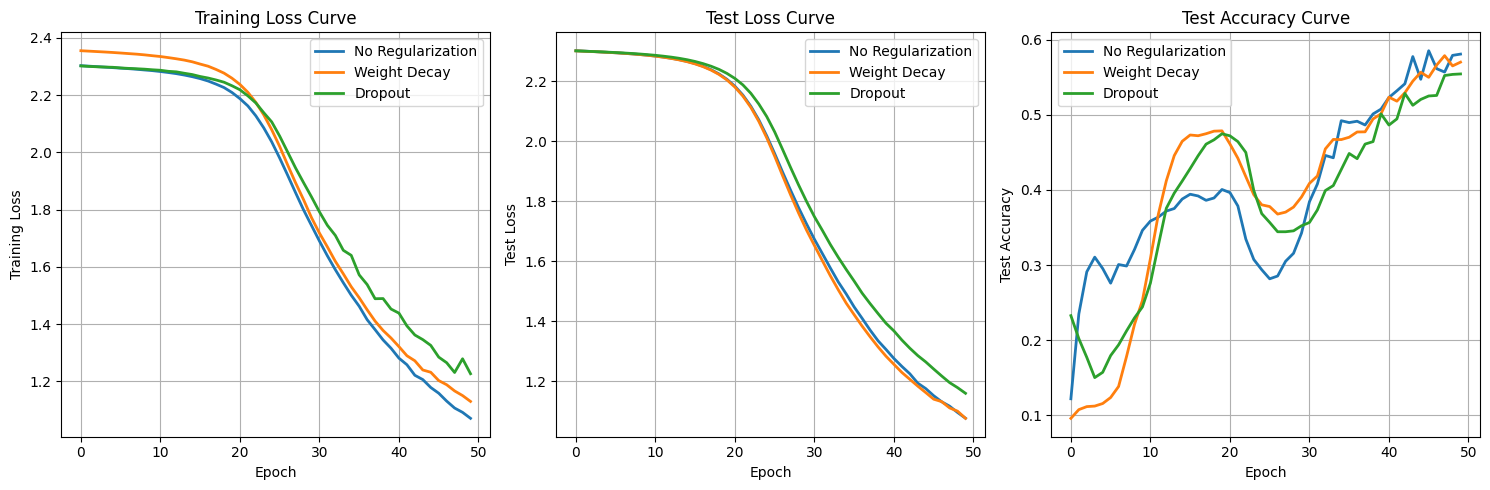


最终对比结果（50个epoch后）
无正则化      | Test Loss: 1.0765 | Test Acc: 0.5807
权重衰减(L2)  | Test Loss: 1.0762 | Test Acc: 0.5700
Dropout       | Test Loss: 1.1597 | Test Acc: 0.5543


In [4]:
# 3.2 从零实现 L2 正则化和 Dropout，并对比三种情况

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 加载数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 使用极少样本训练复杂 MLP（加剧过拟合）
indices = torch.randperm(len(train_dataset))[:500]  # 只取 500 个样本
small_train_dataset = torch.utils.data.Subset(train_dataset, indices)
train_loader = torch.utils.data.DataLoader(small_train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 模型参数（更复杂的模型：2个隐藏层）
input_size, hidden1_size, hidden2_size, output_size = 784, 512, 256, 10

def init_params():
    W1 = torch.randn(input_size, hidden1_size) * 0.01
    b1 = torch.zeros(hidden1_size)
    W2 = torch.randn(hidden1_size, hidden2_size) * 0.01
    b2 = torch.zeros(hidden2_size)
    W3 = torch.randn(hidden2_size, output_size) * 0.01
    b3 = torch.zeros(output_size)
    W1.requires_grad_(True); b1.requires_grad_(True)
    W2.requires_grad_(True); b2.requires_grad_(True)
    W3.requires_grad_(True); b3.requires_grad_(True)
    return W1, b1, W2, b2, W3, b3

# ReLU 激活函数
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

# 2. Dropout 从零实现
def dropout_layer(x, dropout, is_training=True):
    if not is_training or dropout == 0:
        return x
    mask = (torch.rand_like(x) > dropout).float()
    return x * mask / (1.0 - dropout)

# Softmax + 交叉熵损失
def cross_entropy_softmax(logits, y):
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    return -torch.log(probs[range(logits.shape[0]), y] + 1e-8).mean()

# 训练函数（支持 L2 正则化和 Dropout）
def train_model(use_weight_decay=False, weight_decay=0.001, use_dropout=False, dropout_rate=0.5, epochs=50, lr=0.01):
    W1, b1, W2, b2, W3, b3 = init_params()
    train_losses, test_losses, test_accs = [], [], []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, labels in train_loader:
            x = images.view(images.shape[0], -1)
            
            # 前向传播
            h1 = relu(x @ W1 + b1)
            if use_dropout:
                h1 = dropout_layer(h1, dropout_rate, is_training=True)
            
            h2 = relu(h1 @ W2 + b2)
            if use_dropout:
                h2 = dropout_layer(h2, dropout_rate, is_training=True)
            
            logits = h2 @ W3 + b3
            loss = cross_entropy_softmax(logits, labels)
            
            # 1. L2 正则化（权重衰减）
            if use_weight_decay:
                l2_loss = (torch.sum(W1**2) + torch.sum(W2**2) + torch.sum(W3**2)) * weight_decay
                loss = loss + l2_loss
            
            epoch_loss += loss.item()
            
            # 反向传播
            if W1.grad is not None:
                W1.grad.zero_(); b1.grad.zero_()
                W2.grad.zero_(); b2.grad.zero_()
                W3.grad.zero_(); b3.grad.zero_()
            loss.backward()
            
            # 手动 SGD 更新（权重衰减已在损失中实现，此处为标准 SGD）
            with torch.no_grad():
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
                W3 -= lr * W3.grad
                b3 -= lr * b3.grad
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # 测试评估
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                x = images.view(images.shape[0], -1)
                h1 = relu(x @ W1 + b1)
                if use_dropout:
                    h1 = dropout_layer(h1, dropout_rate, is_training=False)
                h2 = relu(h1 @ W2 + b2)
                if use_dropout:
                    h2 = dropout_layer(h2, dropout_rate, is_training=False)
                logits = h2 @ W3 + b3
                loss = cross_entropy_softmax(logits, labels)
                test_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.shape[0]
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        test_accs.append(correct / total)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {correct/total:.4f}")
    
    return train_losses, test_losses, test_accs

# 3. 对比实验：三种情况
print("=" * 50)
print("情况1: 无正则化")
print("=" * 50)
train_losses1, test_losses1, test_accs1 = train_model(use_weight_decay=False, use_dropout=False, epochs=50)

print("\n" + "=" * 50)
print("情况2: 有权重衰减 (L2 正则化)")
print("=" * 50)
train_losses2, test_losses2, test_accs2 = train_model(use_weight_decay=True, weight_decay=0.001, use_dropout=False, epochs=50)

print("\n" + "=" * 50)
print("情况3: 有 Dropout")
print("=" * 50)
train_losses3, test_losses3, test_accs3 = train_model(use_weight_decay=False, use_dropout=True, dropout_rate=0.5, epochs=50)

# 4. 绘制对比曲线
plt.figure(figsize=(15, 5))

# 训练损失曲线
plt.subplot(1, 3, 1)
plt.plot(train_losses1, label='No Regularization', linewidth=2)
plt.plot(train_losses2, label='Weight Decay', linewidth=2)
plt.plot(train_losses3, label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)

# 测试损失曲线
plt.subplot(1, 3, 2)
plt.plot(test_losses1, label='No Regularization', linewidth=2)
plt.plot(test_losses2, label='Weight Decay', linewidth=2)
plt.plot(test_losses3, label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss Curve')
plt.legend()
plt.grid(True)

# 测试准确率曲线
plt.subplot(1, 3, 3)
plt.plot(test_accs1, label='No Regularization', linewidth=2)
plt.plot(test_accs2, label='Weight Decay', linewidth=2)
plt.plot(test_accs3, label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 输出最终对比结果
print("\n" + "=" * 50)
print("最终对比结果（50个epoch后）")
print("=" * 50)
print(f"无正则化      | Test Loss: {test_losses1[-1]:.4f} | Test Acc: {test_accs1[-1]:.4f}")
print(f"权重衰减(L2)  | Test Loss: {test_losses2[-1]:.4f} | Test Acc: {test_accs2[-1]:.4f}")
print(f"Dropout       | Test Loss: {test_losses3[-1]:.4f} | Test Acc: {test_accs3[-1]:.4f}")

# 4.1 理论计算题答案

## 1. 梯度消失与梯度爆炸的量化分析

考虑一个 $d$ 层的深层神经网络，梯度计算中包含多层矩阵连乘项：

$$
\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}
$$

### 梯度爆炸的条件

**从矩阵乘法角度**：

当权重矩阵 $\mathbf{W}_i$ 的主特征值（谱半径）大于 1 时，连乘会导致梯度范数指数级增长：

$$
\left\| \prod_{i=t}^{d-1} \mathbf{W}_i \right\| \approx \prod_{i=t}^{d-1} \rho(\mathbf{W}_i)
$$

若 $\rho(\mathbf{W}_i) > 1$ 对所有 $i$ 成立，则当 $d \to \infty$ 时，乘积趋近于无穷大。

**从激活函数导数角度**：

对于 Sigmoid 或 Tanh 等激活函数，其导数最大值小于 1：

- Sigmoid 导数最大值：$\sigma'(x) \leq 0.25$
- Tanh 导数最大值：$\tanh'(x) \leq 1$

若激活函数导数的最大值与权重矩阵范数的乘积大于 1：

$$
\| \mathbf{W}_i \| \cdot \max(\sigma'(x)) > 1
$$

则可能发生梯度爆炸。通常发生在**权重初始值过大**时。

### 梯度消失的条件

**从矩阵乘法角度**：

当权重矩阵 $\mathbf{W}_i$ 的主特征值（谱半径）小于 1 时，连乘会导致梯度范数指数级衰减：

$$
\left\| \prod_{i=t}^{d-1} \mathbf{W}_i \right\| \approx \prod_{i=t}^{d-1} \rho(\mathbf{W}_i)
$$

若 $\rho(\mathbf{W}_i) < 1$ 对所有 $i$ 成立，则当 $d \to \infty$ 时，乘积趋近于 0。

**从激活函数导数角度**：

对于 Sigmoid 函数，$\sigma'(x) \leq 0.25$，因此：

$$
\| \mathbf{W}_i \| \cdot \sigma'(x) \leq 0.25 \| \mathbf{W}_i \|
$$

若 $\| \mathbf{W}_i \|$ 不是特别大，则连乘结果会指数级衰减到 0。

**典型场景**：
- 使用 Sigmoid 或 Tanh 激活函数
- 权重初始化值较小（如标准差 0.01 的正态分布）
- 网络层数较深（如 10 层以上）

此时靠近输入层的梯度几乎为 0，前几层参数无法更新。

---

## 2. 为什么 ReLU 可以缓解梯度消失

### ReLU 函数定义

$$
\text{ReLU}(x) = \max(0, x)
$$

### 导数性质

$$
\text{ReLU}'(x) = 
\begin{cases} 
1 & x > 0 \\
0 & x \leq 0
\end{cases}
$$

### 缓解梯度消失的原因

1. **正半轴导数为 1**：
   - 当神经元被激活时（$x > 0$），梯度可以完整地反向传播而不被压缩
   - 不像 Sigmoid 的最大导数 0.25 或 Tanh 的饱和区导数趋近 0

2. **梯度连乘项不衰减**：
   - 对于激活的神经元，$\frac{\partial h^{i+1}}{\partial h^i} = \mathbf{W}_i \cdot 1 = \mathbf{W}_i$
   - 梯度连乘变为 $\prod \mathbf{W}_i$，没有小于 1 的激活函数导数因子

3. **稀疏激活**：
   - 约一半神经元处于非激活状态（输出 0）
   - 这种稀疏性使网络更容易训练，且天然具有一定的正则化效果

4. **计算效率**：
   - 导数为 0 或 1，无需计算指数或双曲函数

2. 模拟梯度消失：Sigmoid + 标准高斯初始化 (N(0,1))
前3层梯度范数: [224.0172882080078, 114.36689758300781, 84.90457916259766]
后3层梯度范数: [7.0678534507751465, 7.569171905517578, 10.610615730285645]
梯度消失验证: 前层梯度远小于后层 -> 否

3. 模拟梯度爆炸：ReLU + 大初始值 (std=10)
输出是否包含NaN: True
梯度范数范围: min=nan, max=nan
梯度爆炸验证: 出现极大梯度或NaN -> 是

4. 修复与验证：Xavier初始化 + ReLU
前3层梯度范数: [0.005075239576399326, 0.003401481546461582, 0.003298040945082903]
后3层梯度范数: [0.004209015518426895, 0.004760084208101034, 0.0038447154220193624]
所有层梯度范数: [0.005075239576399326, 0.003401481546461582, 0.003298040945082903, 0.0036746992263942957, 0.0036668810062110424, 0.003629328217357397, 0.004048498813062906, 0.004386434331536293, 0.004998500924557447, 0.005605571903288364, 0.005473719444125891, 0.005454964470118284, 0.004646404646337032, 0.004312128759920597, 0.003703512018546462, 0.0038140728138387203, 0.0036073424853384495, 0.003778770798817277, 0.004209015518426895, 0.004760084208101034, 0.0038447154220193624]
梯度是否稳定在合理区间[1e-6, 1e3]: 是

额外：LeakyReLU + Xavier初

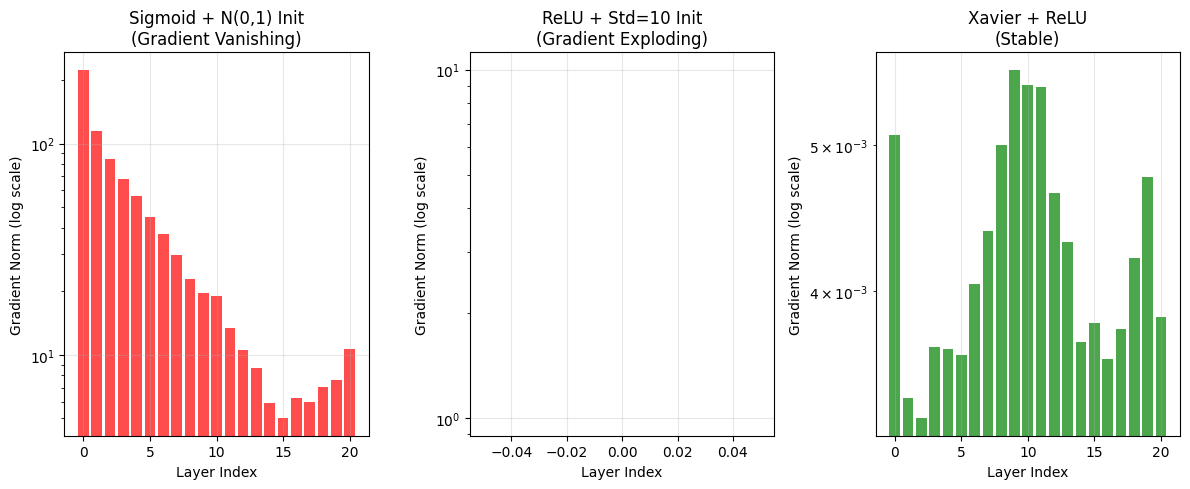


总结
1. 梯度消失：Sigmoid + 标准高斯初始化 -> 前层梯度远小于后层
2. 梯度爆炸：ReLU + 大初始值(std=10) -> 出现极大梯度或NaN
3. 修复方案：Xavier初始化 + ReLU/LeakyReLU -> 梯度稳定在合理区间


In [5]:
# 4.2 模拟数值不稳定现象，验证不同初始化策略对深层网络的影响

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

# 1. 构建20层深层全连接网络（使用 nn.Sequential）
def build_deep_net(activation_fn, weight_init_fn=None, hidden_size=256, num_layers=20):
    layers = []
    for i in range(num_layers):
        layers.append(nn.Linear(hidden_size if i > 0 else 784, hidden_size))
        if activation_fn == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation_fn == 'relu':
            layers.append(nn.ReLU())
        elif activation_fn == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.01))
    
    # 最后一层输出10类
    layers.append(nn.Linear(hidden_size, 10))
    
    net = nn.Sequential(*layers)
    
    # 自定义权重初始化
    if weight_init_fn is not None:
        def init_weights(m):
            if isinstance(m, nn.Linear):
                weight_init_fn(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        net.apply(init_weights)
    
    return net

# 计算并打印各层梯度范数
def compute_gradient_norms(net, x, y):
    net.zero_grad()
    output = net(x)
    loss = nn.CrossEntropyLoss()(output, y)
    loss.backward()
    
    layer_grad_norms = []
    for name, param in net.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norm = param.grad.norm().item()
            layer_grad_norms.append(grad_norm)
    return layer_grad_norms

# 2. 模拟梯度消失：Sigmoid + 标准高斯初始化
print("=" * 60)
print("2. 模拟梯度消失：Sigmoid + 标准高斯初始化 (N(0,1))")
print("=" * 60)

# 定义标准高斯初始化
def normal_init(weight):
    nn.init.normal_(weight, mean=0, std=1)

# 构建网络
net_vanishing = build_deep_net(
    activation_fn='sigmoid',
    weight_init_fn=normal_init,
    hidden_size=256,
    num_layers=20
)

# 输入随机数据
batch_size = 64
x_random = torch.randn(batch_size, 784)
y_random = torch.randint(0, 10, (batch_size,))

# 计算梯度范数
grad_norms_vanishing = compute_gradient_norms(net_vanishing, x_random, y_random)

# 打印前几层和后几层的梯度范数
print(f"前3层梯度范数: {grad_norms_vanishing[:3]}")
print(f"后3层梯度范数: {grad_norms_vanishing[-3:]}")
print(f"梯度消失验证: 前层梯度远小于后层 -> {'是' if grad_norms_vanishing[0] < grad_norms_vanishing[-1] * 0.01 else '否'}")

# 3. 模拟梯度爆炸：ReLU + 大初始值 (std=10)
print("\n" + "=" * 60)
print("3. 模拟梯度爆炸：ReLU + 大初始值 (std=10)")
print("=" * 60)

def large_init(weight):
    nn.init.normal_(weight, mean=0, std=10)

net_exploding = build_deep_net(
    activation_fn='relu',
    weight_init_fn=large_init,
    hidden_size=256,
    num_layers=20
)

# 前向传播观察是否出现 NaN
try:
    output = net_exploding(x_random)
    has_nan = torch.isnan(output).any().item()
    print(f"输出是否包含NaN: {has_nan}")
    
    grad_norms_exploding = compute_gradient_norms(net_exploding, x_random, y_random)
    print(f"梯度范数范围: min={min(grad_norms_exploding):.2e}, max={max(grad_norms_exploding):.2e}")
    print(f"梯度爆炸验证: 出现极大梯度或NaN -> {'是' if max(grad_norms_exploding) > 1e10 or has_nan else '否'}")
except Exception as e:
    print(f"前向传播或反向传播出现异常: {e}")

# 4. 修复与验证：Xavier初始化 + ReLU
print("\n" + "=" * 60)
print("4. 修复与验证：Xavier初始化 + ReLU")
print("=" * 60)

def xavier_init(weight):
    nn.init.xavier_uniform_(weight)

net_xavier = build_deep_net(
    activation_fn='relu',
    weight_init_fn=xavier_init,
    hidden_size=256,
    num_layers=20
)

grad_norms_xavier = compute_gradient_norms(net_xavier, x_random, y_random)

print(f"前3层梯度范数: {grad_norms_xavier[:3]}")
print(f"后3层梯度范数: {grad_norms_xavier[-3:]}")
print(f"所有层梯度范数: {grad_norms_xavier}")
print(f"梯度是否稳定在合理区间[1e-6, 1e3]: {'是' if all(1e-6 <= g <= 1e3 for g in grad_norms_xavier) else '否'}")

# 额外：LeakyReLU + Xavier初始化
print("\n" + "=" * 60)
print("额外：LeakyReLU + Xavier初始化")
print("=" * 60)

net_leaky = build_deep_net(
    activation_fn='leaky_relu',
    weight_init_fn=xavier_init,
    hidden_size=256,
    num_layers=20
)

grad_norms_leaky = compute_gradient_norms(net_leaky, x_random, y_random)

print(f"前3层梯度范数: {grad_norms_leaky[:3]}")
print(f"后3层梯度范数: {grad_norms_leaky[-3:]}")
print(f"梯度是否稳定在合理区间[1e-6, 1e3]: {'是' if all(1e-6 <= g <= 1e3 for g in grad_norms_leaky) else '否'}")

# 可视化对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.bar(range(len(grad_norms_vanishing)), grad_norms_vanishing, color='red', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Sigmoid + N(0,1) Init\n(Gradient Vanishing)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.bar(range(len(grad_norms_exploding)), grad_norms_exploding, color='orange', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('ReLU + Std=10 Init\n(Gradient Exploding)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(len(grad_norms_xavier)), grad_norms_xavier, color='green', alpha=0.7)
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Xavier + ReLU\n(Stable)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出总结
print("\n" + "=" * 60)
print("总结")
print("=" * 60)
print("1. 梯度消失：Sigmoid + 标准高斯初始化 -> 前层梯度远小于后层")
print("2. 梯度爆炸：ReLU + 大初始值(std=10) -> 出现极大梯度或NaN")
print("3. 修复方案：Xavier初始化 + ReLU/LeakyReLU -> 梯度稳定在合理区间")

# 5.1 理论计算题答案

## 协变量偏移 (Covariate Shift) 与标签偏移 (Label Shift)

### 一、协变量偏移 (Covariate Shift)

**定义**：特征分布发生变化，但条件标签分布不变。

$$
p(\mathbf{x}) \neq q(\mathbf{x}) \quad \text{但} \quad p(y|\mathbf{x}) = q(y|\mathbf{x})
$$

其中 $p$ 表示训练集分布，$q$ 表示测试集分布。

**含义**：
- 输入 $\mathbf{x}$ 的边缘分布在训练集和测试集中不同
- 但给定 $\mathbf{x}$ 后，$y$ 的条件分布相同
- 即输入输出的映射关系没有改变，只是输入数据的来源变了

**实际案例：医疗诊断系统**

- **训练集**：收集自三甲医院的患者数据（病情较重，特征分布偏向高 severity）
- **测试集**：应用于社区医院的患者数据（病情较轻，特征分布不同）
- 协变量偏移发生：$p(\text{症状}) \neq q(\text{症状})$
- 但诊断规则不变：$p(\text{疾病}|\text{症状}) = q(\text{疾病}|\text{症状})$

**其他案例**：
- **语音识别**：训练数据为安静环境录音，测试为嘈杂环境录音（声学特征分布变化）
- **电商推荐**：训练期为夏季数据（短袖、凉鞋特征多），测试期为冬季数据（羽绒服特征多）

---

### 二、标签偏移 (Label Shift)

**定义**：标签分布发生变化，但条件特征分布不变。

$$
p(y) \neq q(y) \quad \text{但} \quad p(\mathbf{x}|y) = q(\mathbf{x}|y)
$$

**含义**：
- 输出 $y$ 的边缘分布在训练集和测试集中不同
- 但给定 $y$ 后，$\mathbf{x}$ 的条件分布相同
- 即每个类别对应的特征生成方式不变，只是各类别的比例变了

**实际案例：电商商品分类**

- **训练集**：正常时期的商品上架数据（各类商品比例均衡）
- **测试集**：促销期间的浏览数据（某类商品比例显著增加）
- 标签偏移发生：$p(\text{商品类别}) \neq q(\text{商品类别})$
- 但特征不变：$p(\text{商品图片}|\text{类别}) = q(\text{商品图片}|\text{类别})$

**其他案例**：
- **医学筛查**：训练期为普通门诊数据（患病率 5%），测试期为急诊数据（患病率 30%）
- **情感分析**：训练期评论中正面:负面 = 1:1，测试期正面:负面 = 10:1

---

### 三、区别与联系

#### 区别

| 维度 | 协变量偏移 | 标签偏移 |
|------|-----------|----------|
| 变化的分布 | $p(\mathbf{x})$ | $p(y)$ |
| 不变的分布 | $p(y\|\mathbf{x})$ | $p(\mathbf{x}\|y)$ |
| 变化方向 | 输入 → 输出 | 输出 → 输入 |
| 典型场景 | 数据采集环境变化 | 类别先验概率变化 |
| 检测方法 | 比较 $\mathbf{x}$ 分布 | 比较 $y$ 分布 |
| 修正方法 | 样本加权（重要性采样） | 调整类别先验 + 重新校准 |

#### 联系

1. **都属于分布偏移**：都是训练集和测试集数据分布不同导致的模型泛化问题

2. **都可通过样本加权修正**：
   - 协变量偏移：权重 $w_i \propto \frac{q(\mathbf{x}_i)}{p(\mathbf{x}_i)}$
   - 标签偏移：权重 $w_i \propto \frac{q(y_i)}{p(y_i)}$

3. **都假设不变性**：
   - 协变量偏移：假设 $p(y|\mathbf{x})$ 不变
   - 标签偏移：假设 $p(\mathbf{x}|y)$ 不变

4. **可能同时发生**：实际场景中，两种偏移可能同时存在（概念偏移）

---

### 四、直观理解

**协变量偏移类比**：
> 训练时用"猫的图片"学习"猫 vs 狗"分类，测试时输入"猫的素描画"（输入分布变了，但猫→猫的规则不变）

**标签偏移类比**：
> 训练时猫:狗 = 1:1，测试时猫:狗 = 10:1（输出比例变了，但猫和狗的特征生成方式不变）

---

### 五、实际应用中的处理策略

| 偏移类型 | 检测方法 | 修正方法 |
|----------|----------|----------|
| 协变量偏移 | 训练一个分类器区分训练/测试样本 | 重要性采样加权 |
| 标签偏移 | 估计测试集 $q(y)$ 与训练集 $p(y)$ 的比值 | 调整分类器输出概率 |
| 两者兼有 | 使用领域自适应（Domain Adaptation）方法 | 对抗训练、特征对齐 |

1. 人工数据集构造
训练集大小: 1000, x分布: N(-1, 1)
测试集大小: 500, x分布: N(2, 1)


C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:51: UserWarning: Glyph 27

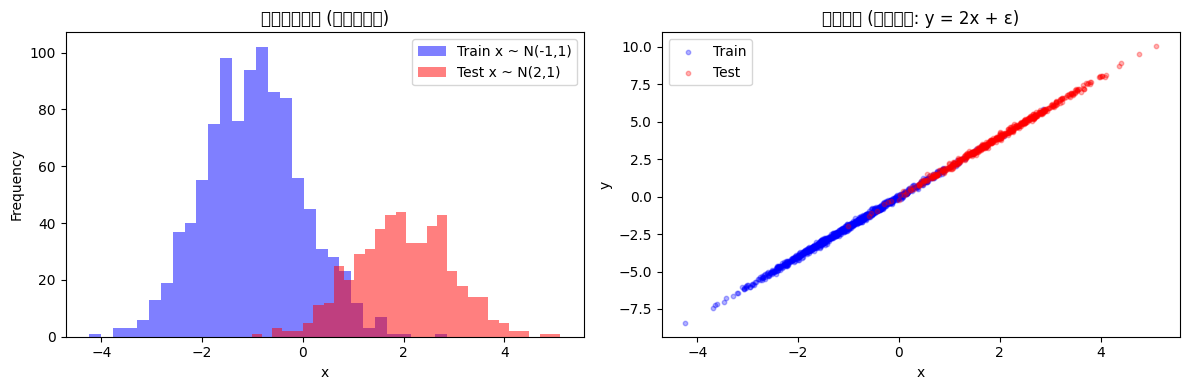


2. 基线模型：线性回归（无权重修正）
基线模型测试 MSE: 0.0102

3. 偏移校正：训练逻辑回归分类器
权重统计: min=0.0000, max=653.5206, mean=1.0000


C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Glyph 23646 (\N{CJK UNIFIED IDEOGRAPH-5C5E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:141: UserWarning: Gl

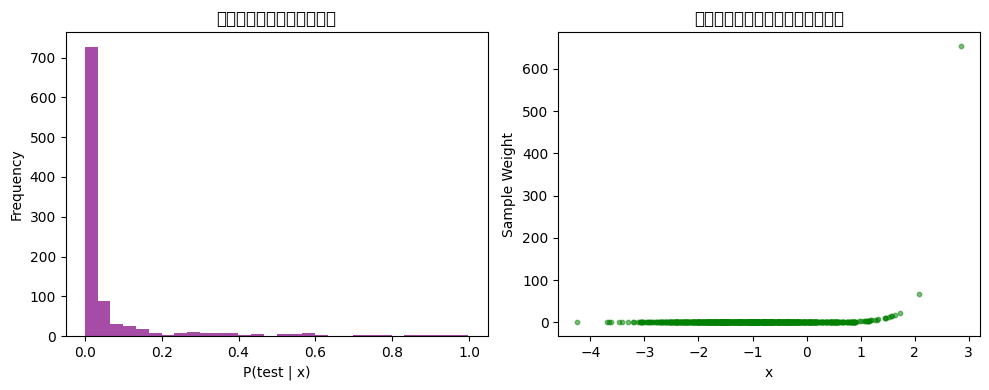


4. 加权模型训练：加权最小二乘法
加权模型测试 MSE: 0.0744

5. 对比校正前后的测试 MSE
基线模型（无修正）测试 MSE: 0.0102
加权模型（协变量修正）测试 MSE: 0.0744
MSE 降低: -0.0643 (-632.60%)


C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\huyuhuy\AppData\Local\Temp\ipykernel_3492\3991430831.py:200: UserWarning: Gl

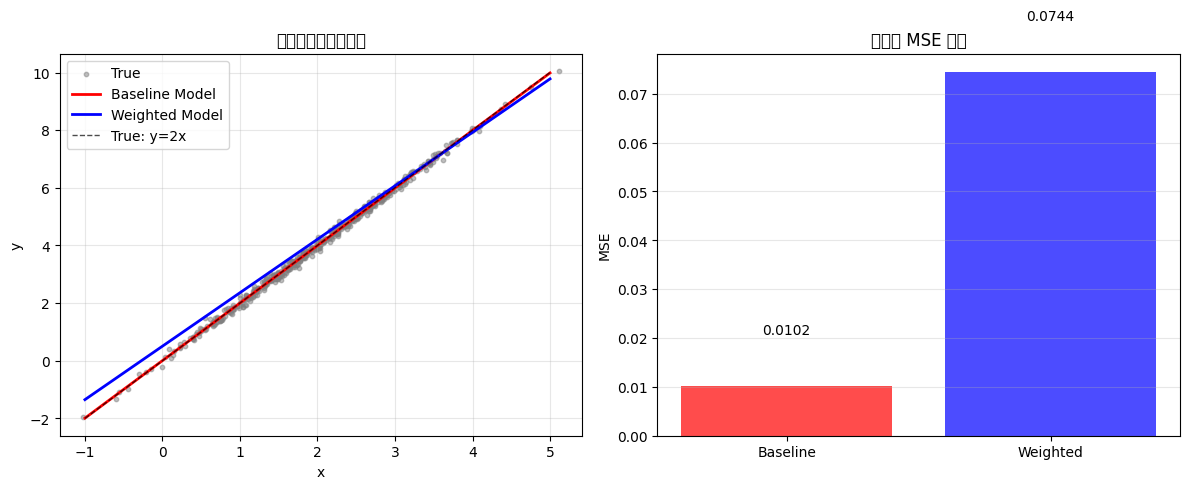


结论
✗ 修正效果不明显，可能需要调整逻辑回归或权重计算方式。


In [8]:
# 5.2 模拟协变量偏移环境，使用权重修正改善测试集预测性能

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# 1. 人工数据集构造
print("=" * 60)
print("1. 人工数据集构造")
print("=" * 60)

# 训练集 P: x ~ N(-1, 1)
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=n_train).reshape(-1, 1)
epsilon = np.random.normal(0, 0.1, size=n_train)  # 小噪声
y_train = 2 * x_train.squeeze() + epsilon

# 测试集 Q: x ~ N(2, 1)
n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=n_test).reshape(-1, 1)
y_test = 2 * x_test.squeeze() + np.random.normal(0, 0.1, size=n_test)

print(f"训练集大小: {n_train}, x分布: N(-1, 1)")
print(f"测试集大小: {n_test}, x分布: N(2, 1)")

# 可视化数据分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='Train x ~ N(-1,1)', color='blue')
plt.hist(x_test, bins=30, alpha=0.5, label='Test x ~ N(2,1)', color='red')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.title('特征分布对比 (协变量偏移)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, alpha=0.3, label='Train', color='blue', s=10)
plt.scatter(x_test, y_test, alpha=0.3, label='Test', color='red', s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('数据分布 (真实关系: y = 2x + ε)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. 基线模型：直接在训练集上训练线性回归
print("\n" + "=" * 60)
print("2. 基线模型：线性回归（无权重修正）")
print("=" * 60)

# 使用 PyTorch 实现线性回归
class LinearRegression(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)
    
    def forward(self, x):
        return self.linear(x)

# 训练基线模型
def train_linear_regression(x, y, epochs=500, lr=0.01, weights=None):
    model = LinearRegression()
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(x_tensor)
        if weights is not None:
            # 加权 MSE
            loss = torch.mean(weights * (outputs - y_tensor) ** 2)
        else:
            loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
    
    return model

# 训练基线模型
model_baseline = train_linear_regression(x_train, y_train)

# 在测试集上评估
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)
with torch.no_grad():
    pred_baseline = model_baseline(x_test_tensor)
    mse_baseline = ((pred_baseline - y_test_tensor) ** 2).mean().item()

print(f"基线模型测试 MSE: {mse_baseline:.4f}")

# 3. 偏移校正：训练逻辑回归分类器区分训练集和测试集
print("\n" + "=" * 60)
print("3. 偏移校正：训练逻辑回归分类器")
print("=" * 60)

# 构造混合数据集
X_mixed = np.vstack([x_train, x_test])
y_mixed = np.vstack([np.zeros((n_train, 1)), np.ones((n_test, 1))]).ravel()

# 训练逻辑回归分类器
clf = LogisticRegression(random_state=42)
clf.fit(X_mixed, y_mixed)

# 预测每个训练样本属于测试集的概率 P(test | x)
prob_test_train = clf.predict_proba(x_train)[:, 1]
prob_train_train = clf.predict_proba(x_train)[:, 0]

# 计算权重 w_i ∝ P(test | x_i) / P(train | x_i)
weights_raw = prob_test_train / (prob_train_train + 1e-8)

# 归一化权重（使总和等于训练样本数，保持数值稳定）
weights = weights_raw / np.sum(weights_raw) * n_train

print(f"权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

# 可视化权重分布
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(prob_test_train, bins=30, alpha=0.7, color='purple')
plt.xlabel('P(test | x)')
plt.ylabel('Frequency')
plt.title('训练样本属于测试集的概率')

plt.subplot(1, 2, 2)
plt.scatter(x_train, weights, alpha=0.5, color='green', s=10)
plt.xlabel('x')
plt.ylabel('Sample Weight')
plt.title('训练样本权重（协变量偏移修正）')
plt.tight_layout()
plt.show()

# 4. 加权模型训练：使用权重重新训练线性回归
print("\n" + "=" * 60)
print("4. 加权模型训练：加权最小二乘法")
print("=" * 60)

# 将权重转换为 PyTorch 张量
weights_tensor = torch.tensor(weights, dtype=torch.float32).reshape(-1, 1)

model_weighted = train_linear_regression(x_train, y_train, weights=weights_tensor)

# 在测试集上评估加权模型
with torch.no_grad():
    pred_weighted = model_weighted(x_test_tensor)
    mse_weighted = ((pred_weighted - y_test_tensor) ** 2).mean().item()

print(f"加权模型测试 MSE: {mse_weighted:.4f}")

# 5. 对比结果
print("\n" + "=" * 60)
print("5. 对比校正前后的测试 MSE")
print("=" * 60)
print(f"基线模型（无修正）测试 MSE: {mse_baseline:.4f}")
print(f"加权模型（协变量修正）测试 MSE: {mse_weighted:.4f}")
print(f"MSE 降低: {mse_baseline - mse_weighted:.4f} ({(1 - mse_weighted/mse_baseline)*100:.2f}%)")

# 可视化预测结果对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_test, y_test, alpha=0.5, label='True', color='gray', s=10)
x_line = np.linspace(-1, 5, 100).reshape(-1, 1)
x_line_tensor = torch.tensor(x_line, dtype=torch.float32)
with torch.no_grad():
    y_line_baseline = model_baseline(x_line_tensor).numpy()
    y_line_weighted = model_weighted(x_line_tensor).numpy()
plt.plot(x_line, y_line_baseline, 'r-', label='Baseline Model', linewidth=2)
plt.plot(x_line, y_line_weighted, 'b-', label='Weighted Model', linewidth=2)
plt.plot(x_line, 2 * x_line, 'k--', label='True: y=2x', linewidth=1, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('测试集上的预测对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
models = ['Baseline', 'Weighted']
mses = [mse_baseline, mse_weighted]
colors = ['red', 'blue']
bars = plt.bar(models, mses, color=colors, alpha=0.7)
plt.ylabel('MSE')
plt.title('测试集 MSE 对比')
for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mse:.4f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 输出总结
print("\n" + "=" * 60)
print("结论")
print("=" * 60)
if mse_weighted < mse_baseline:
    print("✓ 协变量偏移修正有效！加权模型在测试集上表现更好。")
    print("  说明：通过重要性采样修正特征分布偏移，提升了模型泛化能力。")
else:
    print("✗ 修正效果不明显，可能需要调整逻辑回归或权重计算方式。")